In [2]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt 
plt.rc("font", size=14)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)




In [3]:
roads_df = pd.read_csv('C:/Users/Rahul M/Documents/MSc GIS/Dissertation/road_data_compiled_1.csv')

In [4]:
roads_df.shape

(68404, 8)

In [5]:
roads_df.head()

,mean_slope,mean_precipitation,imperviousness,flooded,distance_to_drainage,min_elevation,min_slope,max_slope
0,69.37,9.34,0,1,0.00,671,25.96,106.99
1,3.72,24.31,1,0,3.27,5,0.81,7.80
2,2.31,24.31,13,0,67.17,8,1.28,4.13
3,4.63,25.70,30,0,947.97,7,1.72,8.52
4,7.91,21.94,37,0,463.92,3,4.62,11.48


In [6]:
roads_df.columns


Index(['mean_slope', 'mean_precipitation', 'imperviousness', 'flooded',
       'distance_to_drainage ', 'min_elevation', 'min_slope', 'max_slope'],
      dtype='object')

In [7]:
roads_df['flooded'].value_counts()

0    67639
1      765
Name: flooded, dtype: int64

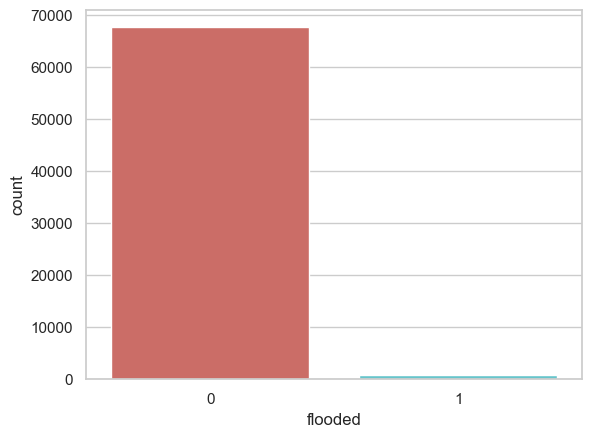

<Figure size 640x480 with 0 Axes>

In [8]:
sns.countplot(x='flooded', data = roads_df, palette = 'hls')
plt.show()
plt.savefig('count_plot')

In [9]:
count_no_flood = len(roads_df[roads_df['flooded']==0])
count_flood = len(roads_df[roads_df['flooded']==1])
pct_of_no_flood = count_no_flood/(count_no_flood+count_flood)
print("percentage of not flooded roads is", pct_of_no_flood*100)
pct_of_flood = count_flood/(count_no_flood+count_flood)
print("percentage of flooded roads is", pct_of_flood*100)

percentage of not flooded roads is 98.88164434828373
percentage of flooded roads is 1.1183556517162738


In [10]:
roads_df.groupby('flooded').mean()

,mean_slope,mean_precipitation,imperviousness,distance_to_drainage,min_elevation,min_slope,max_slope
flooded,,,,,,,
0,10.549722,18.460417,4.952660,259.471149,299.464081,5.416261,16.407194
1,19.327516,16.030275,2.045752,136.820510,511.354248,6.085752,36.773817


In [11]:
X = roads_df.loc[:, roads_df.columns != 'flooded']
y = roads_df.loc[:, roads_df.columns == 'flooded']

from imblearn.over_sampling import SMOTE

os = SMOTE(random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
columns = X_train.columns
os_data_X,os_data_y=os.fit_resample(X_train, y_train)

os_data_X = pd.DataFrame(data=os_data_X,columns=columns )

os_data_y= pd.DataFrame(data=os_data_y,columns=['flooded'])

# we can Check the numbers of our data
print("length of oversampled data is ",len(os_data_X))
print("Number of no flooded in oversampled data",len(os_data_y[os_data_y['flooded']==0]))
print("Number of flooded",len(os_data_y[os_data_y['flooded']==1]))
print("Proportion of no flooded data in oversampled data is ",len(os_data_y[os_data_y['flooded']==0])/len(os_data_X))
print("Proportion of flooded data in oversampled data is ",len(os_data_y[os_data_y['flooded']==1])/len(os_data_X))

length of oversampled data is  94734
Number of no flooded in oversampled data 47367
Number of flooded 47367
Proportion of no flooded data in oversampled data is  0.5
Proportion of flooded data in oversampled data is  0.5


In [16]:
import statsmodels.api as sm
logit_model=sm.Logit(os_data_y,os_data_X)
result=logit_model.fit()
print(result.summary2())

Optimization terminated successfully.
         Current function value: 0.541278
         Iterations 6
                            Results: Logit
Model:                Logit             Method:            MLE        
Dependent Variable:   flooded           Pseudo R-squared:  0.219      
Date:                 2023-10-11 16:35  AIC:               102568.8176
No. Observations:     94734             BIC:               102635.0294
Df Model:             6                 Log-Likelihood:    -51277.    
Df Residuals:         94727             LL-Null:           -65665.    
Converged:            1.0000            LLR p-value:       0.0000     
No. Iterations:       6.0000            Scale:             1.0000     
----------------------------------------------------------------------
                       Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
----------------------------------------------------------------------
mean_slope            -0.1115   0.0044 -25.4066 0.0000 -0.1201 -0.1029
mea

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
X = os_data_X
y= os_data_y['flooded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
logreg = LogisticRegression(max_iter = 1000)
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
y_pred = logreg.predict(X_test)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.74


Confusion matrix

 [[11573  2634]
 [ 4837  9377]]

True Positives(TP) =  11573

True Negatives(TN) =  9377

False Positives(FP) =  2634

False Negatives(FN) =  4837


<Axes: >

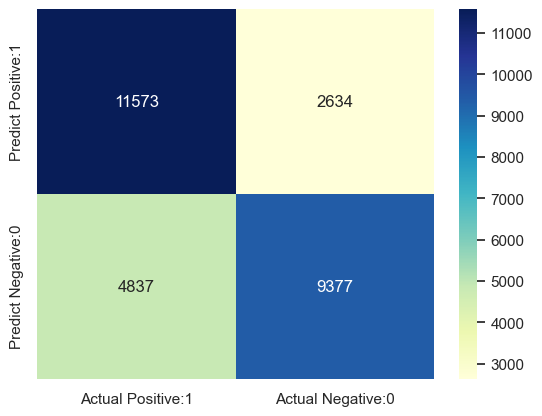

In [20]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print('Confusion matrix\n\n', cm)

print('\nTrue Positives(TP) = ', cm[0,0])

print('\nTrue Negatives(TN) = ', cm[1,1])

print('\nFalse Positives(FP) = ', cm[0,1])

print('\nFalse Negatives(FN) = ', cm[1,0])

# visualize confusion matrix with seaborn heatmap

cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'], 
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

In [21]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.81      0.76     14207
           1       0.78      0.66      0.72     14214

    accuracy                           0.74     28421
   macro avg       0.74      0.74      0.74     28421
weighted avg       0.74      0.74      0.74     28421



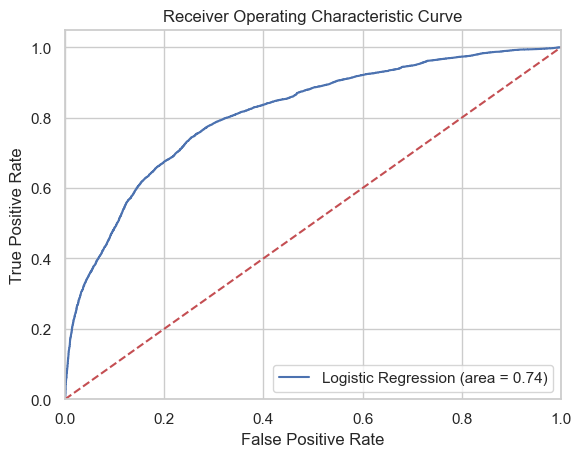

In [39]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, logreg.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, logreg.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

In [22]:
from sklearn.model_selection import cross_val_score
logreg = LogisticRegression(max_iter=1000)
k = 5  # Number of folds
scores = cross_val_score(logreg, X, y, cv=k, scoring='accuracy')
print(f"Accuracy: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

Accuracy: 0.7367 (+/- 0.0046)
